In [1]:
!pip install bertopic sentence-transformers umap-learn hdbscan -q


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# =========================
# 1. Import libraries
# =========================

import json
import re
from pathlib import Path

import pandas as pd
import numpy as np


# =========================
# 2. File paths
# =========================

DATA_DIR = Path("/home/renku/work/analysis-of-corporate-reports-dataset")

LM_PATH = "Loughran-McDonald_MasterDictionary_1993-2025.csv"


# =========================
# 3. SIC code → Industry sector
# =========================

SIC_TO_SECTOR = {
    "2000": "Consumer Staples",
    "2080": "Consumer Staples",
    "2111": "Consumer Staples",
    "2810": "Materials",
    "2834": "Healthcare",
    "2836": "Healthcare",
    "2840": "Consumer Staples",
    "2844": "Consumer Staples",
    "2911": "Energy",
    "3021": "Consumer Discretionary",
    "3523": "Industrials",
    "3531": "Industrials",
    "3570": "Technology",
    "3571": "Technology",
    "3576": "Technology",
    "3600": "Industrials",
    "3663": "Technology",
    "3674": "Technology",
    "3711": "Consumer Discretionary",
    "3721": "Industrials",
    "3724": "Industrials",
    "3730": "Industrials",
    "3760": "Industrials",
    "3823": "Healthcare",
    "3829": "Healthcare",
    "3841": "Healthcare",
    "3842": "Healthcare",
    "3845": "Healthcare",
    "4011": "Industrials",
    "4210": "Industrials",
    "4513": "Industrials",
    "4812": "Communication Services",
    "4813": "Communication Services",
    "4841": "Communication Services",
    "4911": "Utilities",
    "4931": "Utilities",
    "5211": "Consumer Discretionary",
    "5331": "Consumer Discretionary",
    "5810": "Consumer Discretionary",
    "5812": "Consumer Discretionary",
    "5912": "Healthcare",
    "5961": "Consumer Discretionary",
    "6021": "Financials",
    "6022": "Financials",
    "6199": "Financials",
    "6211": "Financials",
    "6311": "Financials",
    "6324": "Healthcare",
    "6331": "Financials",
    "6798": "Real Estate",
    "7370": "Technology",
    "7372": "Technology",
    "7389": "Financials",
    "7841": "Communication Services",
    "7990": "Communication Services",
}


# =========================
# 4. Load Loughran-McDonald Dictionary
# =========================

lm = pd.read_csv(LM_PATH)

lm["Word"] = lm["Word"].str.lower()

negative_words = set(lm.loc[lm["Negative"] > 0, "Word"])
positive_words = set(lm.loc[lm["Positive"] > 0, "Word"])
uncertainty_words = set(lm.loc[lm["Uncertainty"] > 0, "Word"])
litigious_words = set(lm.loc[lm["Litigious"] > 0, "Word"])

print(lm.columns)
lm.head()

Index(['Word', 'Seq_num', 'Word Count', 'Word Proportion',
       'Average Proportion', 'Std Dev', 'Doc Count', 'Negative', 'Positive',
       'Uncertainty', 'Litigious', 'Strong_Modal', 'Weak_Modal',
       'Constraining', 'Complexity', 'Syllables', 'Source'],
      dtype='str')


,Word,Seq_num,Word Count,Word Proportion,Average Proportion,Std Dev,Doc Count,Negative,Positive,Uncertainty,Litigious,Strong_Modal,Weak_Modal,Constraining,Complexity,Syllables,Source
0,aardvark,1,814,3.085383e-08,2.022181e-08,4.059339e-06,158,0,0,0,0,0,0,0,0,2,12of12inf
1,aardvarks,2,3,1.137119e-10,7.898767e-12,8.829342e-09,1,0,0,0,0,0,0,0,0,2,12of12inf
2,abaci,3,9,3.411357e-10,1.067549e-10,5.054031e-08,7,0,0,0,0,0,0,0,0,3,12of12inf
3,aback,4,29,1.099215e-09,6.073925e-10,1.523804e-07,28,0,0,0,0,0,0,0,0,2,12of12inf
4,abacus,5,9921,3.760453e-07,3.836730e-07,3.392121e-05,1355,0,0,0,0,0,0,0,0,3,12of12inf


In [3]:
# =========================
# 5. ESG keyword dictionary
# =========================

E_KEYWORDS = [
    "environment", "environmental", "climate", "carbon", "emission", "emissions",
    "greenhouse gas", "ghg", "energy", "renewable", "waste", "water",
    "pollution", "recycling", "biodiversity", "sustainability", "net zero"
]

S_KEYWORDS = [
    "employee", "employees", "workforce", "labor", "human capital",
    "health", "safety", "training", "diversity", "inclusion",
    "community", "human rights", "wellbeing", "talent"
]

G_KEYWORDS = [
    "governance", "board", "director", "audit", "ethics", "compliance",
    "anti-corruption", "bribery", "risk management", "internal control",
    "cybersecurity", "data privacy", "shareholder", "transparency"
]

ESG_KEYWORDS = E_KEYWORDS + S_KEYWORDS + G_KEYWORDS

In [4]:
# =========================
# 6. Helper functions
# =========================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def split_paragraphs(text):
    text = str(text)
    paragraphs = re.split(r"\n+|\.\s+", text)
    return [p.strip() for p in paragraphs if len(p.strip()) > 20]


def extract_year(data):
    date = data.get("period_of_report") or data.get("filing_date")
    if pd.isna(date) or date == "":
        return np.nan
    return str(date)[:4]


def extract_esg_text(text):
    paragraphs = split_paragraphs(text)
    
    esg_paragraphs = [
        p for p in paragraphs
        if any(keyword in p.lower() for keyword in ESG_KEYWORDS)
    ]
    
    return " ".join(esg_paragraphs)


def count_keywords(text, keywords):
    text = str(text).lower()
    return sum(text.count(k.lower()) for k in keywords)


def count_lm_words(text, word_set):
    words = clean_text(text).split()
    return sum(1 for w in words if w in word_set)




In [5]:
# =========================
# 7. Load all 10-K JSON files
# =========================

files = list(DATA_DIR.glob("*.json"))

records = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    company = data.get("company", "")
    cik = data.get("cik", "")
    sic = str(data.get("sic", ""))
    sector = SIC_TO_SECTOR.get(sic, "Unknown")
    year = extract_year(data)
    
    full_text = " ".join([
        str(data.get("item_1", "")),
        str(data.get("item_1A", "")),
        str(data.get("item_7", ""))
    ])
    
    esg_text = extract_esg_text(full_text)
    
    records.append({
        "filename": file.name,
        "cik": cik,
        "company": company,
        "sic": sic,
        "sector": sector,
        "year": year,
        "filing_type": data.get("filing_type", ""),
        "filing_date": data.get("filing_date", ""),
        "period_of_report": data.get("period_of_report", ""),
        "full_text": clean_text(full_text),
        "esg_text": clean_text(esg_text),
        "full_word_count": len(clean_text(full_text).split()),
        "esg_word_count": len(clean_text(esg_text).split()),
    })

df = pd.DataFrame(records)

df.head()

,filename,cik,company,sic,sector,year,filing_type,filing_date,period_of_report,full_text,esg_text,full_word_count,esg_word_count
0,1001039_10K_2016_0001001039-16-000516.json,1001039,WALT DISNEY CO/,4841,Communication Services,2016,10-K,2016-11-23,2016-10-01,item business the walt disney company together...,operating expenses primarily consist of progra...,24518,1903
1,1001039_10K_2017_0001001039-17-000198.json,1001039,WALT DISNEY CO/,4841,Communication Services,2017,10-K,2017-11-22,2017-09-30,item business the walt disney company together...,operating expenses primarily consist of progra...,23714,1898
2,1001039_10K_2018_0001001039-18-000187.json,1001039,WALT DISNEY CO/,4841,Communication Services,2018,10-K,2018-11-21,2018-09-29,item business the walt disney company together...,operating expenses primarily consist of progra...,26922,1924
3,100885_10K_2016_0000100885-17-000056.json,100885,UNION PACIFIC CORP,4011,Industrials,2016,10-K,2017-02-03,2016-12-31,item business general union pacific railroad c...,union pacific provides value to its roughly cu...,17197,3714
4,100885_10K_2017_0000100885-18-000048.json,100885,UNION PACIFIC CORP,4011,Industrials,2017,10-K,2018-02-09,2017-12-31,item business general union pacific railroad c...,union pacific provides value to its roughly cu...,17759,3743


In [6]:
# =========================
# 8. Add ESG keyword scores
# =========================

df["E_score"] = df["esg_text"].apply(lambda x: count_keywords(x, E_KEYWORDS))
df["S_score"] = df["esg_text"].apply(lambda x: count_keywords(x, S_KEYWORDS))
df["G_score"] = df["esg_text"].apply(lambda x: count_keywords(x, G_KEYWORDS))

df["total_esg_score"] = df["E_score"] + df["S_score"] + df["G_score"]

df["esg_intensity"] = df["esg_word_count"] / df["full_word_count"]


# =========================
# 9. Add Loughran-McDonald sentiment scores
# =========================

df["lm_negative"] = df["esg_text"].apply(lambda x: count_lm_words(x, negative_words))
df["lm_positive"] = df["esg_text"].apply(lambda x: count_lm_words(x, positive_words))
df["lm_uncertainty"] = df["esg_text"].apply(lambda x: count_lm_words(x, uncertainty_words))
df["lm_litigious"] = df["esg_text"].apply(lambda x: count_lm_words(x, litigious_words))


# =========================
# 10. Final company-year table
# =========================

company_year_table = df[[
    "company",
    "cik",
    "year",
    "sic",
    "sector",
    "filing_date",
    "full_word_count",
    "esg_word_count",
    "esg_intensity",
    "E_score",
    "S_score",
    "G_score",
    "total_esg_score",
    "lm_negative",
    "lm_positive",
    "lm_uncertainty",
    "lm_litigious"
]].copy()

company_year_table.head()

,company,cik,year,sic,sector,filing_date,full_word_count,esg_word_count,esg_intensity,E_score,S_score,G_score,total_esg_score,lm_negative,lm_positive,lm_uncertainty,lm_litigious
0,WALT DISNEY CO/,1001039,2016,4841,Communication Services,2016-11-23,24518,1903,0.077616,15,68,10,93,30,18,26,11
1,WALT DISNEY CO/,1001039,2017,4841,Communication Services,2017-11-22,23714,1898,0.080037,14,66,8,88,28,18,26,10
2,WALT DISNEY CO/,1001039,2018,4841,Communication Services,2018-11-21,26922,1924,0.071466,14,72,8,94,36,16,31,10
3,UNION PACIFIC CORP,100885,2016,4011,Industrials,2017-02-03,17197,3714,0.215968,120,118,28,266,106,39,69,89
4,UNION PACIFIC CORP,100885,2017,4011,Industrials,2018-02-09,17759,3743,0.210766,124,112,29,265,107,38,68,95


In [7]:
year_summary = (
    company_year_table
    .groupby("year")
    .agg(
        n_companies=("company", "count"),
        avg_esg_intensity=("esg_intensity", "mean"),
        avg_E_score=("E_score", "mean"),
        avg_S_score=("S_score", "mean"),
        avg_G_score=("G_score", "mean"),
        avg_lm_negative=("lm_negative", "mean"),
        avg_lm_uncertainty=("lm_uncertainty", "mean")
    )
    .reset_index()
)

year_summary

,year,n_companies,avg_esg_intensity,avg_E_score,avg_S_score,avg_G_score,avg_lm_negative,avg_lm_uncertainty
0,2016,97,0.154304,72.639175,85.515464,60.824742,98.721649,80.515464
1,2017,98,0.155345,69.959184,84.346939,59.306122,99.551020,80.581633
2,2018,98,0.159679,85.428571,91.061224,64.806122,114.346939,90.244898
3,2019,99,0.163526,71.282828,92.565657,63.818182,116.252525,86.323232
4,2020,99,0.182314,75.565657,150.333333,72.242424,136.565657,103.232323
5,2021,100,0.202425,91.600000,172.700000,76.490000,152.000000,115.000000
6,2022,100,0.215995,101.580000,170.560000,80.070000,165.070000,120.480000
7,2023,101,0.218844,104.851485,168.079208,85.623762,177.495050,126.257426
8,2024,100,0.217286,104.180000,155.100000,88.070000,184.520000,128.040000
9,2025,100,0.213147,95.900000,146.090000,87.520000,185.740000,128.810000


In [8]:
industry_summary = (
    company_year_table
    .groupby("sector")
    .agg(
        n_companies=("company", "count"),
        avg_esg_intensity=("esg_intensity", "mean"),
        avg_E_score=("E_score", "mean"),
        avg_S_score=("S_score", "mean"),
        avg_G_score=("G_score", "mean"),
        avg_lm_negative=("lm_negative", "mean"),
        avg_lm_uncertainty=("lm_uncertainty", "mean")
    )
    .reset_index()
    .sort_values("avg_esg_intensity", ascending=False)
)

industry_summary

,sector,n_companies,avg_esg_intensity,avg_E_score,avg_S_score,avg_G_score,avg_lm_negative,avg_lm_uncertainty
11,Utilities,30,0.376695,651.000000,87.433333,56.566667,254.033333,245.833333
3,Energy,30,0.324311,230.566667,62.533333,36.166667,97.233333,71.333333
5,Healthcare,160,0.239327,56.018750,266.300000,78.681250,201.068750,120.300000
7,Materials,10,0.196347,157.600000,57.100000,44.200000,71.300000,65.200000
2,Consumer Staples,70,0.190361,112.200000,155.928571,75.814286,185.000000,115.328571
1,Consumer Discretionary,110,0.189741,76.172727,89.663636,45.309091,116.409091,70.072727
10,Unknown,10,0.182237,44.400000,135.300000,67.900000,155.000000,117.400000
4,Financials,200,0.172425,58.610000,107.895000,137.675000,164.565000,171.940000
6,Industrials,117,0.169688,99.239316,109.239316,43.367521,105.957265,69.128205
9,Technology,175,0.152261,41.171429,116.051429,60.257143,115.120000,71.360000


In [11]:
# 11. TF-IDF — Top ESG Keywords per Year
# =========================

# 1. รวม ESG text ของทุกบริษัทในแต่ละปี
year_docs = (
    df.groupby("year", as_index=False)
      .agg({"esg_text": lambda x: " ".join(x.astype(str))})
)

# ลบ year ว่าง
year_docs = year_docs[
    year_docs["year"].notna() &
    (year_docs["year"] != "")
]

year_docs = year_docs.sort_values("year")

print("Number of year documents:", len(year_docs))

# 2. TF-IDF
vectorizer = TfidfVectorizer(
    max_features=200,
    ngram_range=(1,2),
    stop_words="english",
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(
    year_docs["esg_text"]
)

feature_names = vectorizer.get_feature_names_out()

# 3. สร้าง DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=year_docs["year"]
)

tfidf_df.head()

top_keywords_by_year = {}

for year in tfidf_df.index:

    row = tfidf_df.loc[year]

    top_terms = (
        row.sort_values(ascending=False)
           .head(20)
    )

    top_keywords_by_year[year] = list(top_terms.index)

    print(f"\n===== {year} =====")
    print(top_terms)

Number of year documents: 10

===== 2016 =====
energy           0.239723
including        0.221807
business         0.206897
products         0.200077
health           0.199846
risk             0.199037
management       0.177191
financial        0.175689
costs            0.168176
employees        0.153381
company          0.149798
compliance       0.144828
operations       0.130495
related          0.122635
regulations      0.120902
laws             0.119515
services         0.113735
environmental    0.111424
board            0.106800
certain          0.104720
Name: 2016, dtype: float64

===== 2017 =====
energy           0.235361
including        0.219546
business         0.218500
products         0.207802
health           0.205592
risk             0.193266
financial        0.171056
management       0.169776
costs            0.165009
employees        0.150240
compliance       0.146636
company          0.145705
operations       0.133961
related          0.126518
laws             0.12593

In [12]:
results = []

for year in tfidf_df.index:

    row = tfidf_df.loc[year]

    top_terms = (
        row.sort_values(ascending=False)
           .head(20)
    )

    for keyword, score in top_terms.items():

        results.append({
            "year": year,
            "keyword": keyword,
            "tfidf_score": score
        })

top_keywords_df = pd.DataFrame(results)

top_keywords_df.head()

,year,keyword,tfidf_score
0,2016,energy,0.239723
1,2016,including,0.221807
2,2016,business,0.206897
3,2016,products,0.200077
4,2016,health,0.199846


=== Top 15 TF-IDF keywords per year ===

0.03282604883005822: energy, including, business, products, health, risk, management, financial, costs, employees, company, compliance, operations, related, regulations

0.03697869641876033: energy, including, business, products, health, risk, financial, management, costs, employees, compliance, company, operations, related, laws

0.04235216670480898: energy, including, health, business, products, risk, costs, financial, company, management, compliance, employees, operations, related, laws

0.03939888136181459: including, health, business, products, energy, risk, financial, employees, costs, management, compliance, company, operations, laws, regulations

0.03502841811865747: including, employees, health, business, products, risk, energy, financial, company, management, costs, compliance, operations, related, laws

0.035550877455100625: including, employees, business, health, products, company, risk, financial, costs, management, energy, complian

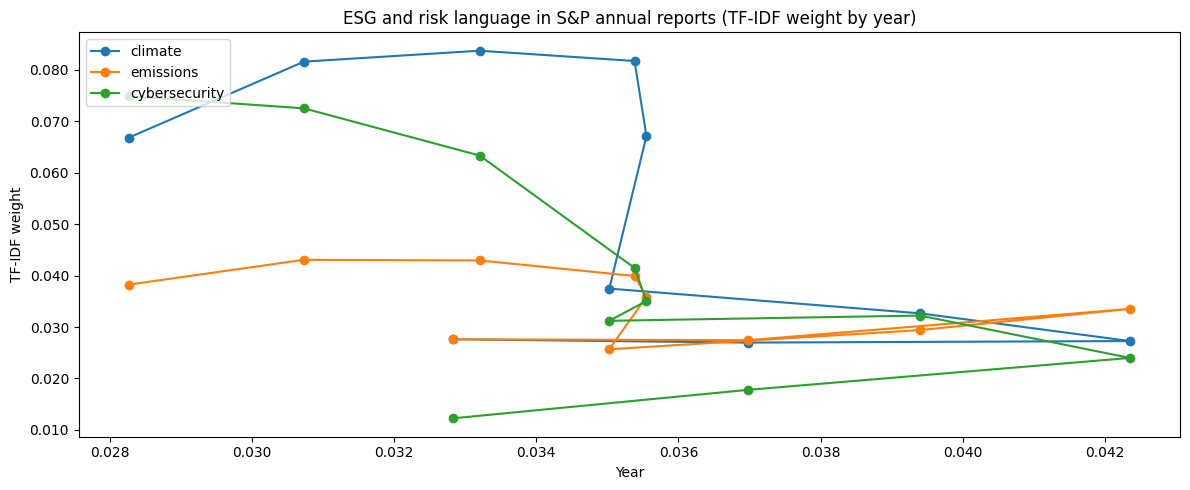

Saved: esg_trend_tfidf.png


In [13]:
# Top 15 keywords per year
print("=== Top 15 TF-IDF keywords per year ===")
top_keywords_by_year = {}
for _, row in tfidf_df.iterrows():
    year = row["year"]
    scores = row.drop("year").sort_values(ascending=False).head(15)
    top_keywords_by_year[year] = scores
    print(f"\n{year}: {', '.join(scores.index.tolist())}")

# --- Track specific terms over time ---
TRACK_TERMS = ["climate", "sustainability", "emissions", "cybersecurity", "diversity", "pandemic"]

track_data = {}
for term in TRACK_TERMS:
    if term in tfidf_df.columns:
        track_data[term] = tfidf_df.set_index("year")[term]

track_df = pd.DataFrame(track_data)

fig, ax = plt.subplots(figsize=(12, 5))
for col in track_df.columns:
    ax.plot(track_df.index, track_df[col], marker="o", label=col)
ax.set_title("ESG and risk language in S&P annual reports (TF-IDF weight by year)")
ax.set_xlabel("Year")
ax.set_ylabel("TF-IDF weight")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
plt.tight_layout()
plt.savefig("esg_trend_tfidf.png", dpi=150)
plt.show()
print("Saved: esg_trend_tfidf.png")

In [14]:
# 12. Topic Modeling — BERTopic on ESG Paragraphs
# =========================

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# --- 12a. Build paragraph-level corpus ---
# Each row = one paragraph from one company-year document
para_records = []
for _, row in df.iterrows():
    paragraphs = [p.strip() for p in re.split(r"\n+|\.\s+", str(row["esg_text"])) if len(p.strip()) > 40]
    for p in paragraphs:
        para_records.append({
            "company": row["company"],
            "year": row["year"],
            "sector": row["sector"],
            "paragraph": p
        })

para_df = pd.DataFrame(para_records)
print(f"Total ESG paragraphs: {len(para_df):,}")

# --- 12b. Embed paragraphs ---
# Uses Snowflake Arctic (available on Swiss AI) or falls back to MiniLM locally
# To use Swiss AI embedding endpoint, replace with your client.embeddings.create() loop

EMBED_MODEL = "Snowflake/snowflake-arctic-embed-l-v2.0"

try:
    # Local sentence-transformers path (fast, no API key needed)
    embed_model = SentenceTransformer("all-MiniLM-L6-v2")
    print("Using local all-MiniLM-L6-v2 for embeddings")
except Exception:
    embed_model = SentenceTransformer(EMBED_MODEL)
    print(f"Using {EMBED_MODEL}")

docs = para_df["paragraph"].tolist()
print(f"Embedding {len(docs):,} paragraphs…")
embeddings = embed_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {embeddings.shape}")

# --- 12c. Configure BERTopic components ---
umap_model = UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=20,     # minimum paragraphs per topic
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# Remove generic stopwords + add ESG-specific ones to avoid trivial topics
custom_stopwords = list(TfidfVectorizer(stop_words="english").get_stop_words()) + [
    "company", "companies", "including", "also", "may", "year", "annual",
    "report", "business", "fiscal", "quarter", "period"
]

vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words=custom_stopwords,
    min_df=5
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    nr_topics="auto",           # let HDBSCAN decide; reduce with nr_topics=30 if too many
    top_n_words=10,
    calculate_probabilities=False,
    verbose=True
)

# --- 12d. Fit BERTopic ---
topics, _ = topic_model.fit_transform(docs, embeddings)
para_df["topic_id"] = topics

print(f"\nNumber of topics found: {topic_model.get_topic_info().shape[0] - 1}")  # -1 for outlier topic -1
print("\nTop topics:")
print(topic_model.get_topic_info().head(20).to_string(index=False))

/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total ESG paragraphs: 941


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5493.98it/s]


Using local all-MiniLM-L6-v2 for embeddings
Embedding 941 paragraphs…


Batches: 100%|██████████| 15/15 [00:17<00:00,  1.15s/it]
2026-06-09 18:58:39,727 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Embeddings shape: (941, 384)


2026-06-09 18:58:50,487 - BERTopic - Dimensionality - Completed ✓
2026-06-09 18:58:50,488 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 18:58:50,509 - BERTopic - Cluster - Completed ✓
2026-06-09 18:58:50,509 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-09 18:58:54,960 - BERTopic - Representation - Completed ✓
2026-06-09 18:58:54,961 - BERTopic - Topic reduction - Reducing number of topics
2026-06-09 18:58:54,967 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 18:58:59,614 - BERTopic - Representation - Completed ✓
2026-06-09 18:58:59,616 - BERTopic - Topic reduction - Reduced number of topics from 20 to 15
IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (b

In [15]:
# =========================
# 13. Assign E / S / G label to each topic
# =========================

# Rule-based mapping: check top-10 words of each topic against E/S/G keyword lists
E_SET = set(E_KEYWORDS)
S_SET = set(S_KEYWORDS)
G_SET = set(G_KEYWORDS)

def assign_esg_label(topic_id):
    """Return 'E', 'S', 'G', or 'Other' based on majority of top-10 words."""
    if topic_id == -1:
        return "Outlier"
    words = [w for w, _ in topic_model.get_topic(topic_id)]
    scores = {"E": 0, "S": 0, "G": 0}
    for w in words:
        w_lower = w.lower()
        if any(k in w_lower for k in E_SET):
            scores["E"] += 1
        if any(k in w_lower for k in S_SET):
            scores["S"] += 1
        if any(k in w_lower for k in G_SET):
            scores["G"] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "Other"

topic_info = topic_model.get_topic_info().copy()
topic_info["esg_label"] = topic_info["Topic"].apply(assign_esg_label)
topic_info["top_words"] = topic_info["Topic"].apply(
    lambda t: ", ".join([w for w, _ in topic_model.get_topic(t)][:6]) if t != -1 else ""
)

# Map label back to paragraph df
label_map = dict(zip(topic_info["Topic"], topic_info["esg_label"]))
para_df["esg_label"] = para_df["topic_id"].map(label_map)

print("\n=== ESG label distribution across topics ===")
print(topic_info.groupby("esg_label")["Count"].sum().sort_values(ascending=False))

print("\n=== Sample topics with labels ===")
print(
    topic_info[topic_info["Topic"] != -1][["Topic", "Count", "esg_label", "top_words"]]
    .sort_values("Count", ascending=False)
    .head(20)
    .to_string(index=False)
)


=== ESG label distribution across topics ===
esg_label
S          328
G          227
Outlier    207
E          179
Name: Count, dtype: int64

=== Sample topics with labels ===
 Topic  Count esg_label                                                           top_words
     0    227         G risk, management, risk management, financial, employees, compliance
     1    169         S           employees, data, compliance, customers, employee, related
     2     40         E              energy, registrants, gas, power, southern, natural gas
     3     40         E  energy, energy transportation, emissions, oil, transportation, gas
     4     35         S             employees, costs, labor, operations, emissions, express
     5     34         S             health, care, health care, services, benefits, medicare
     6     28         E  environmental, solutions, safety, technologies, climate, employees
     7     27         S        healthcare, collaboration, products, product, safety, he


=== ESG label proportions by sector ===
esg_label               total  E_pct  S_pct  G_pct
sector                                            
Financials              162.0    0.0   38.9   61.1
Healthcare              123.0    0.0   91.9    8.1
Technology              104.0    0.0   84.6   15.4
Industrials             101.0   60.4   18.8   20.8
Consumer Discretionary   70.0   35.7   14.3   50.0
Consumer Staples         50.0   40.0    0.0   60.0
Communication Services   44.0    0.0   63.6   36.4
Energy                   30.0  100.0    0.0    0.0
Utilities                30.0  100.0    0.0    0.0
Materials                10.0  100.0    0.0    0.0
Unknown                  10.0   30.0   70.0    0.0


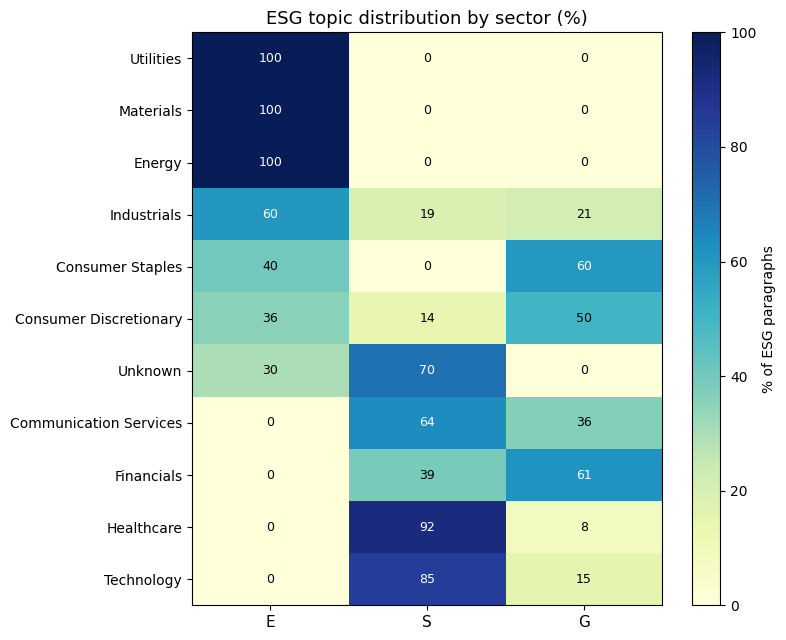

Saved: esg_sector_heatmap.png

=== Most prominent topic per sector ===
                sector  topic_id esg_label                                                           top_words  count
Communication Services         1         S           employees, data, compliance, customers, employee, related     28
Consumer Discretionary         0         G risk, management, risk management, financial, employees, compliance     35
      Consumer Staples         0         G risk, management, risk management, financial, employees, compliance     30
                Energy         3         E  energy, energy transportation, emissions, oil, transportation, gas     30
            Financials         0         G risk, management, risk management, financial, employees, compliance     99
            Healthcare         7         S        healthcare, collaboration, products, product, safety, health     27
           Industrials         8         E environmental, costs, systems, government, remediation, regu

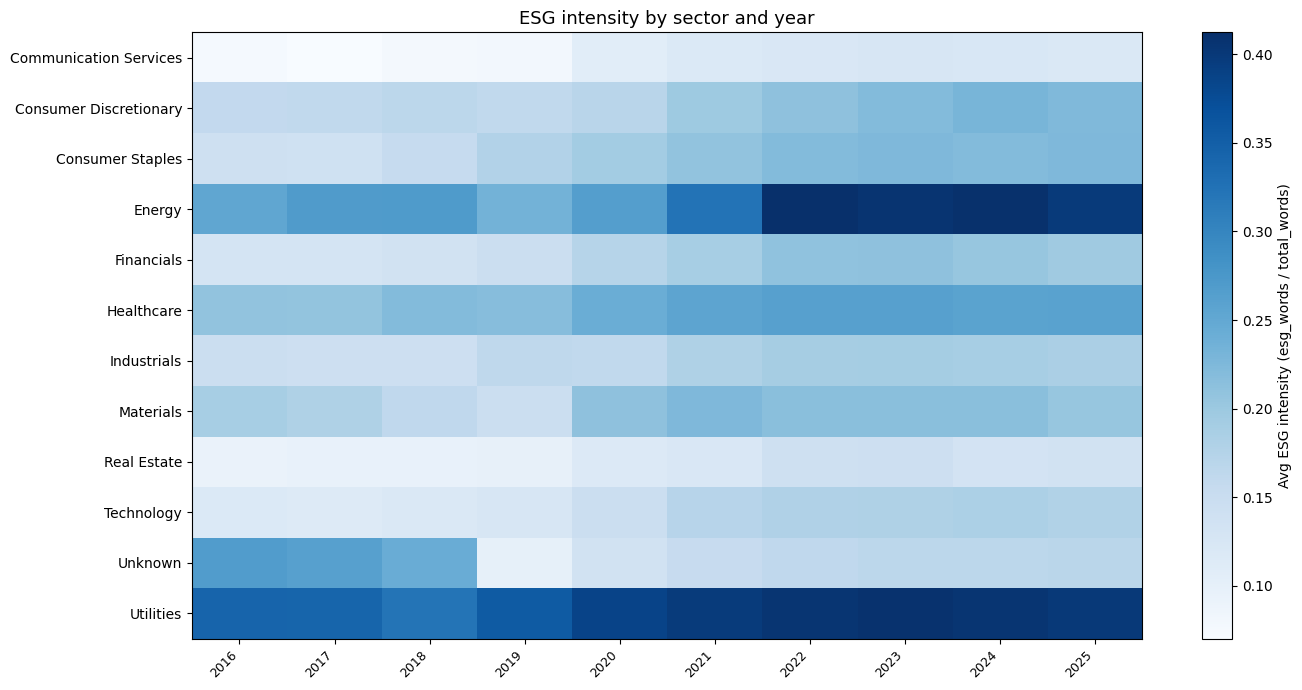

Saved: esg_intensity_sector_year.png

All outputs saved.


In [17]:
# =========================
# 15. Compare Industries
# =========================

# --- 15a. Topic distribution per sector ---
# Exclude outliers
para_filtered = para_df[para_df["topic_id"] != -1].copy()

# Count paragraphs per sector × esg_label
sector_esg = (
    para_filtered
    .groupby(["sector", "esg_label"])
    .size()
    .reset_index(name="count")
)

# Pivot to wide
sector_esg_pivot = sector_esg.pivot(index="sector", columns="esg_label", values="count").fillna(0)
sector_esg_pivot["total"] = sector_esg_pivot.sum(axis=1)

# Normalize to proportions
for col in ["E", "S", "G", "Other"]:
    if col in sector_esg_pivot.columns:
        sector_esg_pivot[f"{col}_pct"] = sector_esg_pivot[col] / sector_esg_pivot["total"] * 100

print("\n=== ESG label proportions by sector ===")
print(sector_esg_pivot[[c for c in sector_esg_pivot.columns if "_pct" in c or c == "total"]]
      .sort_values("total", ascending=False)
      .round(1)
      .to_string())

# --- 15b. Heatmap: sector × esg_label ---
pct_cols = [c for c in sector_esg_pivot.columns if "_pct" in c]
heatmap_data = sector_esg_pivot[pct_cols].copy()
heatmap_data.columns = [c.replace("_pct", "") for c in pct_cols]
heatmap_data = heatmap_data.sort_values("E", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(heatmap_data) * 0.5 + 1)))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=11)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=10)
plt.colorbar(im, ax=ax, label="% of ESG paragraphs")
ax.set_title("ESG topic distribution by sector (%)", fontsize=13)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=9,
                color="white" if val > 50 else "black")
plt.tight_layout()
plt.savefig("esg_sector_heatmap.png", dpi=150)
plt.show()
print("Saved: esg_sector_heatmap.png")

# --- 15c. Top topic per sector ---
top_topic_per_sector = (
    para_filtered
    .groupby(["sector", "topic_id"])
    .size()
    .reset_index(name="count")
    .sort_values(["sector", "count"], ascending=[True, False])
    .groupby("sector")
    .first()
    .reset_index()
    .merge(topic_info[["Topic", "esg_label", "top_words"]], left_on="topic_id", right_on="Topic", how="left")
    [["sector", "topic_id", "esg_label", "top_words", "count"]]
)

print("\n=== Most prominent topic per sector ===")
print(top_topic_per_sector.to_string(index=False))

# --- 15d. Year × Sector ESG intensity heatmap ---
year_sector = (
    company_year_table
    .groupby(["year", "sector"])
    .agg(avg_esg_intensity=("esg_intensity", "mean"))
    .reset_index()
    .pivot(index="sector", columns="year", values="avg_esg_intensity")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(14, max(4, len(year_sector) * 0.5 + 1)))
im = ax.imshow(year_sector.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(year_sector.columns)))
ax.set_xticklabels(year_sector.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(year_sector.index)))
ax.set_yticklabels(year_sector.index, fontsize=10)
plt.colorbar(im, ax=ax, label="Avg ESG intensity (esg_words / total_words)")
ax.set_title("ESG intensity by sector and year", fontsize=13)
plt.tight_layout()
plt.savefig("esg_intensity_sector_year.png", dpi=150)
plt.show()
print("Saved: esg_intensity_sector_year.png")

# --- 15e. Save enriched dataframe ---
para_df.to_csv("esg_paragraphs_with_topics.csv", index=False)
company_year_table.to_csv("company_year_esg_table.csv", index=False)
topic_info.to_csv("bertopic_topic_info.csv", index=False)
print("\nAll outputs saved.")